In [ ]:
# Linear, Polynomial and Logistic Regression from Scratch (Python)

This notebook demonstrates the implementation of linear, polynomial and logistic regression using Python and NumPy, on Car prices, specifically on price per horsepower.

The goal of this project is to understand how classification models work at a mathematical and algorithmic level, rather than treating them as black boxes.

At a high level, the model works by:
1. Combining input features into a linear equation
2. Passing the result through a sigmoid function to obtain probabilities
3. Training the model using gradient descent to reduce prediction error

To follow along, please run the cells in order from top to bottom. Each section builds on the previous one, and outputs are displayed to illustrate how the model learns.

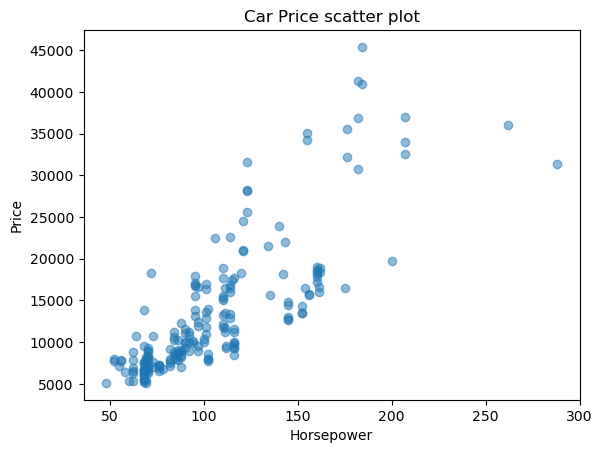

In [14]:
# Base imports of dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Import the Car Price file
df = pd.read_csv('CarPrice_Assignment.csv')

# Start with just numeric features
x = df[['horsepower']]
y = df['price']

# Check out some missing values
x.isnull().sum()
y.isnull().sum()

# Drop rows with missing values
df = df.dropna()

# Scatter Plot
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Car Price scatter plot')
plt.scatter(x, y, alpha=0.5)
plt.show()

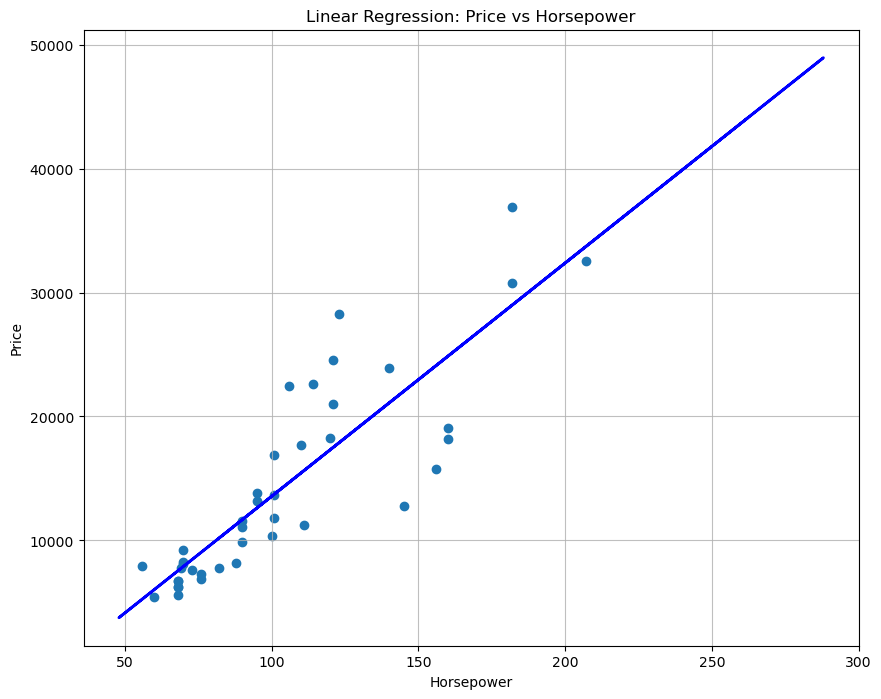

In [109]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Training model and split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.8,
    random_state = 45,
)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

# Plot
plt.figure(figsize=(10, 8))
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.title("Linear Regression: Price vs Horsepower")
plt.scatter(x_train, y_train)
plt.plot(x_test, y_pred, color='b', linewidth=2)
plt.grid(True, alpha=0.8)
plt.show()

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


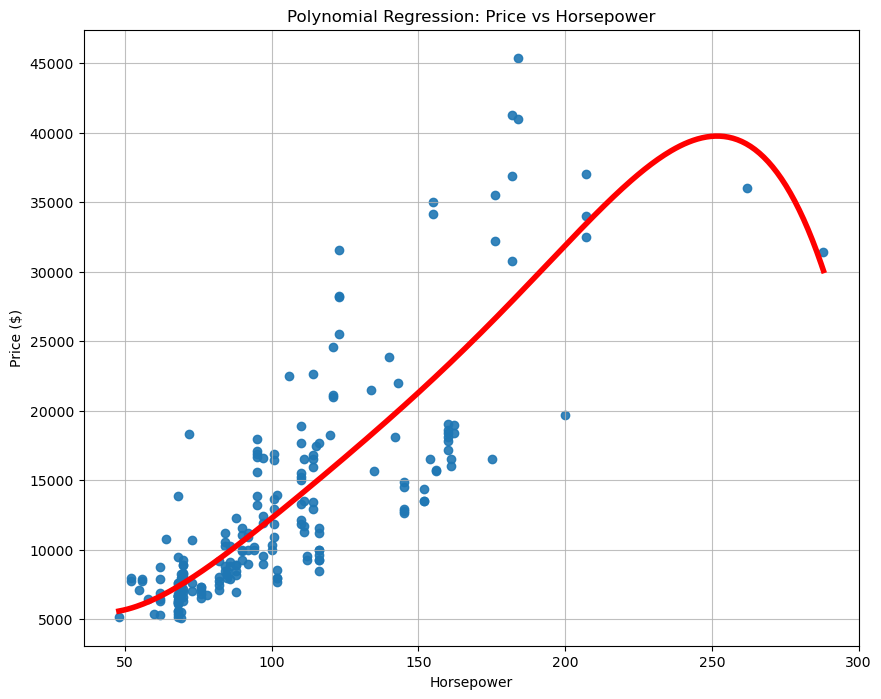

In [107]:
# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures

# Split the dataset into training and testing sets
# Try changing the test size and random state to see and experiment with different graphs
x_train, x_test, y_train, y_test = train_test_split(
    x, y,                # x = input, y = output
    test_size = 0.35,    # Number of samples to use for testing (here: exactly 1 data point)
    random_state = 45,   # Fixes the randomness so the split is reproducible every time
)

# Creating the polynomial
poly = PolynomialFeatures(degree=5) # Try changing the degree and see how it changes
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

model = LinearRegression()
model.fit(x_train_poly, y_train)

y_pred = model.predict(x_test_poly)

# Sort for smooth curve plotting
x_plot = np.linspace(x.min(), x.max(), 320).reshape(-2, 1)
x_plot_poly = poly.transform(x_plot)
y_plot = model.predict(x_plot_poly)

plt.figure(figsize=(10, 8))
plt.scatter(x, y, alpha=0.9, label='Actual data')
plt.plot(x_plot, y_plot, 'r-', linewidth=4, label=f'Polynomial fit (degree={poly.degree})')
plt.xlabel('Horsepower')
plt.ylabel('Price ($)')
plt.title('Polynomial Regression: Price vs Horsepower')
plt.grid(True, alpha=0.8)
plt.show()